## Simulaciones del modelo Zenteno por pasos

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from procesamiento_datos import process_excel

### Definición del modelo de ecuaciones diferenciales:

In [2]:
# -------------------------------- Utilidades numéricas --------------------------------
EPS = 1e-9
BIG = 1e6  # techo de seguridad para estados y tasas


def safe_div(a, b, eps=EPS):
    return a / (b + eps)


def safe_exp(x, lo=-50.0, hi=50.0):
    """exp con saturación del exponente para evitar overflow/underflow extremo."""
    return np.exp(np.clip(x, lo, hi))


def clamp(x, lo, hi):
    return np.minimum(np.maximum(x, lo), hi)


def _real_pos(z):
    """Parte real y clamp a >= 0 (evita ComplexWarning y negativos numéricos)."""
    r = float(np.real(z))
    return r if r > 0.0 else 0.0

In [3]:
# -------------------------------- Modelo dinámico --------------------------------
def zenteno_model(t, x, u, p, apply_nadd_in_model=True):
    """
    Modelo de cinética de fermentación robusto.
    Estados: x = [X, N, G, F, E] (g/L)
    Entradas: u = [T (K), Nadd (g/L/h)]  (Nadd se suma a dN si apply_nadd_in_model=True)
    Parámetros: p[0..13] positivos.
    """
    # Entradas
    T = float(u[0])     # Kelvin
    Nadd = float(u[1])  # g/L/h     
            
    # Estados (no-negatividad y parte real)
    X = _real_pos(x[0])
    N = _real_pos(x[1])
    G = _real_pos(x[2])
    F = _real_pos(x[3])
    E = _real_pos(x[4])

    # Limitar T a un rango físico razonable (0-60 °C)
    T = clamp(T, 273.15, 333.15)

    # Parámetros (positivos)
    vals = [max(float(pi), EPS) for pi in p]
    (mu0, betaG0, betaF0, Kn0, Kg0, Kf0, Kig0, Kie0, Kd0,
     Yxn, Yxg, Yxf, Yeg, Yef) = vals

    # Constantes
    Cde     = 0.0415      # m3/kg E (Salmon 2003)
    Etd     = 130000.0    # kJ/kmol
    R       = 8.314       # kJ/kmol/K (Boulton 1979)
    Eac     = 59453.0     # kJ/kmol (Boulton 1979)
    Eafe    = 11000.0     # kJ/kmol (Zenteno 2010)
    EaKn    = 46055.0     # kJ/kmol (Boulton 1979)
    EaKg    = 46055.0     # kJ/kmol (Boulton 1979)
    EaKf    = 46055.0     # kJ/kmol (Boulton 1979)
    EaKig   = 46055.0     # kJ/kmol (Boulton 1979)
    EaKie   = 46055.0     # kJ/kmol (Boulton 1979)
    Eam     = 37681.0     # kJ/kmol (Boulton 1979)
    m0      = 0.01        # kgS/kg bio/h

    # Arrhenius con exponente acotado
    mu_max    = mu0   * safe_exp(Eac *(T-300.00)/(300.00*R*T))
    betaG_max = betaG0* safe_exp(Eafe*(T-296.15)/(296.15*R*T))
    betaF_max = betaF0* safe_exp(Eafe*(T-296.15)/(296.15*R*T))
    Kn        = Kn0   * safe_exp(EaKn*(T-293.15)/(293.15*R*T))
    Kg        = Kg0   * safe_exp(EaKg*(T-293.15)/(293.15*R*T))
    Kf        = Kf0   * safe_exp(EaKf*(T-293.15)/(293.15*R*T))
    Kig       = Kig0  * safe_exp(EaKig*(T-293.15)/(293.15*R*T))
    Kie       = Kie0  * safe_exp(EaKie*(T-293.15)/(293.15*R*T))
    m         = m0    * safe_exp(Eam *(T-293.30)/(293.30*R*T))

    # Tasas con divisiones seguras
    mu      = mu_max * safe_div(N, N + Kn)
    beta_G  = betaG_max* safe_div(G, G + Kg) * safe_div(Kie, E + Kie)
    beta_F  = betaF_max* safe_div(F, F + Kf) * safe_div(Kig, G + Kig) * safe_div(Kie, E + Kie)

    # Temperatura de muerte térmica con E acotado (evita E**3 enorme)
    E_cap = clamp(E, 0.0, 200.0)
    Td = -0.0001*(E_cap**3) + 0.0049*(E_cap**2) - 0.1279*E_cap + 315.89
    Td = clamp(Td, 273.15, 333.15)

    # Tasa de muerte específica con exponencial segura
    if T >= Td:
        exponent = (Cde*E_cap) + safe_div(Etd*(T-305.65), (305.65*R*T))
        Kd = Kd0 * safe_exp(exponent, lo=-50.0, hi=50.0)
    else:
        Kd = 0.0

    # Mezcla para mantenimiento (evita 0/0)
    GpF = G + F + EPS
    mG = G / GpF
    mF = F / GpF

    # EDOs
    dX = (mu - Kd) * X
    dN = -(mu / max(Yxn, EPS)) * X
    if apply_nadd_in_model:
        dN += Nadd  # Nadd se agrega como tasa en el paso correspondiente
    dG = -((mu / max(Yxg, EPS)) + (beta_G / max(Yeg, EPS)) + m*mG) * X
    dF = -((mu / max(Yxf, EPS)) + (beta_F / max(Yef, EPS)) + m*mF) * X
    dE = (beta_G + beta_F) * X

    dX = float(clamp(dX, -BIG, BIG))
    dN = float(clamp(dN, -BIG, BIG))
    dG = float(clamp(dG, -BIG, BIG))
    dF = float(clamp(dF, -BIG, BIG))
    dE = float(clamp(dE, -BIG, BIG))
    return np.array([dX, dN, dG, dF, dE], dtype=float)

### Definición de entradas al integrados del sistema ODE:

Vectores de tiempo:

In [ ]:
# t_span (TUPLA): define el intervalo total de integración (inicio y fin, obligatorio)

# t_eval (VECTOR): especifica los puntos de tiempo exactos donde se desea obtener 
# y almacenar la solución (opcional)

tiempos_datos = np.linspace(0, 5*24, 41) 
print("Tiempos de datos (horas):", [f"{t:.2f}" for t in tiempos_datos])

Parámetros:

In [ ]:
# params = [0.277041, 0.428944, 0.516588, 0.009647, 8.551854, 7.165650, 44.150670, 42.528284, 0.01,
#         28.923223, 3.330956, 1.642634, 0.780173, 0.879215]

#params = [0.197200, 0.229613, 0.248792, 0.017264, 26.204288, 7.165650, 134.167400, 42.528284, 0.01,
#          35.363591, 15.347849, 7.769926, 0.451746, 0.836931]

# MODEL_2264 = {"fixed": {"Kn0": 0.009647, "Kg0": 8.551854, "Kf0": 7.165650, "Kig0": 44.150670,
#        "Kie0": 42.528284, "Yxf": 1.642634, }, "free": {"mu0": 0.277041, "betaG0": 0.428944,
#        "betaF0": 0.516588, "Yxn": 28.923223, "Yxg": 3.330956, "Yeg": 0.780173, "Yef": 0.879215,}}

# MODEL_1750 = mu0 fijo = 0.197200, betaG0 fijo = 0.229613, betaF0 fijo = 0.248792, Kn0 libre = 0.017264
# Kg0 libre = 26.204288, Kf0 fijo = 7.165650, Kig0 libre = 134.167400, Kie0 fijo = 42.528284, Yxn libre = 35.363591
# Yxg libre = 15.347849, Yxf libre = 7.769926, Yeg fijo = 0.451746, Yef libre = 0.836931

In [73]:
# MIOS: mu0 = 5.094427, betaG0 = 5.451988, betaF0 = 2.878541, Kn0 = 2.967765
# Kg0 = 429.934043, Kf0 = 279.361563, Kig0 = 123.736979, Kie0 = 278.362199, Kd0 = 0.000100
# Yxn = 5.797756, Yxg = 118.306831, Yxf = 103.880857, Yeg = 0.578462, Yef = 0.405039

params = [5.094427, 5.451988, 2.878541, 2.967765, 429.934043, 279.361563, 123.736979, 278.362199, 0.000100,
          5.797756, 118.306831, 103.880857, 0.578462, 0.405039]

Condiciones iniciales de variables de estado:

In [ ]:
biomasa_inicial = 0.08 # g/L
azucar_inicial = 240 # g/L
YAN_inicial = 0.150 # g/L
etanol_inicial = 0.0 # g/L

Entradas del vector u:

In [ ]:
Temp_span = []
Nadd_span = []
for i in range(len(tiempos_datos)):
    # Definición de la temperatura
    if i < 10:
        Temp_span.append(273.15 + 20.0) # Kelvin
    elif i > 13:
        Temp_span.append(273.15 + 20.0) # Kelvin
    else: 
        Temp_span.append(273.15 + 15.0) # Kelvin
        
    # Definición de la adición de nitrógeno
    if tiempos_datos[i] > 38 and tiempos_datos[i] < 41: 
        Nadd_span.append(0.05) # g/L/h
    else: 
        Nadd_span.append(0.0) # g/L/h
        
        
print("Temperaturas (K):", [f"{T:.2f}" for T in Temp_span])
print("Adición de nitrógeno (g/L/h):", [f"{Nadd:.3f}" for Nadd in Nadd_span])  

### Métodos de simulación

#### Método 1: RK4

In [ ]:
def RK4_method(f, tf, x0, n, u, params):
    """
    Método Runge-Kutta explicito de 4to orden para integrar ODE.
    
    Entrada:
    f (function): función de python con el sistema ODE
    t0 (float): valor inicial de integración
    tf (float): valor del tiempo final de integración
    x0 (array): vector condiciones inicales (m)
    n (float): número de pasos o elementos finitos en el tiempo
    u (array): vector variable manipulada (n + 1)    
    
    Salida:
    t (array): vector tiempo de integración (n + 1)
    x (array): vector de estados integrados (n + 1, m)
    """  
    h = tf/n
    t = np.zeros(n+1)
    x = np.array((n+1)*[x0])
    t[0] = 0.0
    x[0] = x0
    
    for k in range(n):
        
        k1 = f(t[k],x[k],u[k], params)
        k2 = f(t[k]+h/2,x[k]+(h/2)*k1,u[k], params)
        k3 = f(t[k]+h/2,x[k]+(h/2)*k2,u[k], params)
        k4 = f(t[k]+h,x[k]+h*k3,u[k], params)
        x[k+1] = x[k]+(h/6)*(k1+2*k2+2*k3+k4)
        t[k+1] = t[k]+h
    
    return t,x

In [ ]:
x0_m1 = np.array([biomasa_inicial, YAN_inicial, azucar_inicial/2, azucar_inicial/2, etanol_inicial])
n_m1 = len(tiempos_datos) - 1
print(f'Número de pasos de integración: {n_m1}')

In [ ]:
t_m1,x_m1 = RK4_method(f = zenteno_model, tf = tiempos_datos[-1],
                       x0 = x0_m1, n = n_m1, u = list(zip(Temp_span, Nadd_span)), 
                       params = params)

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(t_m1, x_m1[:,0], '-', label='$X_{RK4}$ (g/L)')
plt.plot(t_m1, x_m1[:,1]*1000, '-', label='$N_{RK4}$ (mg/L)')
plt.plot(t_m1, x_m1[:,2], '-', label='$G_{RK4}$ (g/L)')
plt.plot(t_m1, x_m1[:,3], '-', label='$F_{RK4}$ (g/L)')
plt.plot(t_m1, x_m1[:,4], '-', label='$E_{RK4}$ (g/L)')
plt.title('Simulación de fermentación con RK4 y u variable')
plt.ylabel('Concentración')
plt.xlabel('Tiempo (h)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### Método 2: solve_ivp en todo el horizonte

##### Con BDF

In [5]:
def zenteno_ode_u_variable(t, x, params, t_eval, T_grid, Nadd_grid):
    idx = np.searchsorted(t_eval, t, side="right") - 1
    # idx = np.clip(idx, 0, len(T_grid)-1)  # seguridad

    u = [float(T_grid[idx]), float(Nadd_grid[idx])]
    return zenteno_model(t, x, u, params)


In [ ]:
x0_m2 = np.array([biomasa_inicial, YAN_inicial, azucar_inicial/2, azucar_inicial/2, etanol_inicial])
tspan = (tiempos_datos[0], tiempos_datos[-1])

res_m2_BDF = solve_ivp(fun = zenteno_ode_u_variable, t_span = tspan,  y0 = x0_m2,  
                   method = 'BDF', t_eval = tiempos_datos, 
                   args = (params, tiempos_datos, Temp_span, Nadd_span))

In [ ]:
t_m2_BDF = res_m2_BDF.t
x_m2_BDF = res_m2_BDF.y.T

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(t_m2_BDF, x_m2_BDF[:,0], '-', label='$X_{scipy1\_BDF}$ (g/L)')
plt.plot(t_m2_BDF, x_m2_BDF[:,1]*1000, '-', label='$N_{scipy1\_BDF}$ (mg/L)')
plt.plot(t_m2_BDF, x_m2_BDF[:,2], '-', label='$G_{scipy1\_BDF}$ (g/L)')
plt.plot(t_m2_BDF, x_m2_BDF[:,3], '-', label='$F_{scipy1\_BDF}$ (g/L)')
plt.plot(t_m2_BDF, x_m2_BDF[:,4], '-', label='$E_{scipy1\_BDF}$ (g/L)')
plt.title('Simulación de fermentación con solve_ivp en todo el horizonte y u variable')
plt.ylabel('Concentración')
plt.xlabel('Tiempo (h)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

##### Con LSODA

In [ ]:
res_m2_LSODA = solve_ivp(fun = zenteno_ode_u_variable, t_span = tspan,  y0 = x0_m2,  
                   method = 'LSODA', t_eval = tiempos_datos, 
                   args = (params, tiempos_datos, Temp_span, Nadd_span))

In [ ]:
t_m2_LSODA = res_m2_LSODA.t
x_m2_LSODA = res_m2_LSODA.y.T

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(t_m2_BDF, x_m2_BDF[:,0], '-', label='$X_{scipy1\_BDF}$ (g/L)')
plt.plot(t_m2_BDF, x_m2_BDF[:,1]*1000, '-', label='$N_{scipy1\_BDF}$ (mg/L)')
plt.plot(t_m2_BDF, x_m2_BDF[:,2], '-', label='$G_{scipy1\_BDF}$ (g/L)')
plt.plot(t_m2_BDF, x_m2_BDF[:,3], '-', label='$F_{scipy1\_BDF}$ (g/L)')
plt.plot(t_m2_BDF, x_m2_BDF[:,4], '-', label='$E_{scipy1\_BDF}$ (g/L)')

plt.plot(t_m2_LSODA, x_m2_LSODA[:,0], '--', label='$X_{scipy1\_LSODA}$ (g/L)')
plt.plot(t_m2_LSODA, x_m2_LSODA[:,1]*1000, '--', label='$N_{scipy1\_LSODA}$ (mg/L)')
plt.plot(t_m2_LSODA, x_m2_LSODA[:,2], '--', label='$G_{scipy1\_LSODA}$ (g/L)')
plt.plot(t_m2_LSODA, x_m2_LSODA[:,3], '--', label='$F_{scipy1\_LSODA}$ (g/L)')
plt.plot(t_m2_LSODA, x_m2_LSODA[:,4], '--', label='$E_{scipy1\_LSODA}$ (g/L)')

plt.title('Simulación de fermentación con solve_ivp en todo el horizonte y u variable')
plt.ylabel('Concentración')
plt.xlabel('Tiempo (h)')
plt.legend(fontsize=8)
plt.grid(True)

plt.tight_layout()
plt.show()

##### Con Radau

In [ ]:
res_m2_Radau = solve_ivp(fun = zenteno_ode_u_variable, t_span = tspan,  y0 = x0_m2,  
                   method = 'Radau', t_eval = tiempos_datos, 
                   args = (params, tiempos_datos, Temp_span, Nadd_span))

In [ ]:
t_m2_Radau = res_m2_Radau.t
x_m2_Radau = res_m2_Radau.y.T

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(t_m2_BDF, x_m2_BDF[:,0], '-', label='$X_{scipy1\_BDF}$ (g/L)')
plt.plot(t_m2_BDF, x_m2_BDF[:,1]*1000, '-', label='$N_{scipy1\_BDF}$ (mg/L)')
plt.plot(t_m2_BDF, x_m2_BDF[:,2], '-', label='$G_{scipy1\_BDF}$ (g/L)')
plt.plot(t_m2_BDF, x_m2_BDF[:,3], '-', label='$F_{scipy1\_BDF}$ (g/L)')
plt.plot(t_m2_BDF, x_m2_BDF[:,4], '-', label='$E_{scipy1\_BDF}$ (g/L)')
plt.plot(t_m2_Radau, x_m2_Radau[:,0], '--', label='$X_{scipy1\_Radau}$ (g/L)')
plt.plot(t_m2_Radau, x_m2_Radau[:,1]*1000, '--', label='$N_{scipy1\_Radau}$ (mg/L)')
plt.plot(t_m2_Radau, x_m2_Radau[:,2], '--', label='$G_{scipy1\_Radau}$ (g/L)')
plt.plot(t_m2_Radau, x_m2_Radau[:,3], '--', label='$F_{scipy1\_Radau}$ (g/L)')
plt.plot(t_m2_Radau, x_m2_Radau[:,4], '--', label='$E_{scipy1\_Radau}$ (g/L)')

plt.title('Simulación de fermentación con solve_ivp en todo el horizonte y u variable')
plt.ylabel('Concentración')
plt.xlabel('Tiempo (h)')
plt.legend(fontsize=8)
plt.grid(True)

plt.tight_layout()
plt.show()

**Cada 2 horas** el peak de nitrógeno no se ve bien con métodos como RK45 ni Radau. 
Si se ve con LSODA y BDF

**Cada 3 horas** el peak de nitrógeno no se ve bien con BDF. 
Si se ve con Radau y LSODA

**CONCLUSIÓN** el "mejor" se ve que es LSODA.

#### Método 3: solve_ivp “paso a paso” (stepwise)

In [ ]:
x0_m3 = np.array([biomasa_inicial, YAN_inicial, azucar_inicial/2, azucar_inicial/2, etanol_inicial])
x_m3 = np.zeros([len(tiempos_datos), len(x0_m3)]) 

for i in range(len(tiempos_datos) - 1):
    # calculamos el paso en cada iteración
    h = tiempos_datos[i+1] - tiempos_datos[i]
    # El tiempo tspan siempre será de 0 a h
    tspan = (0, h)
    
    # Resolvemos la ODE para el intervalo actual con las condiciones iniciales correspondientes
    res = solve_ivp(fun = zenteno_model, t_span = tspan, y0 = x0_m3, method='LSODA', 
                    args= ((Temp_span[i], Nadd_span[i]), params))
    
    # la condiciones finales de esta iteración son el valor de los estados en  i
    
    x_i = res.y.T[-1, :]  # obtenemos el último punto de la solución
    
    x_m3[i,:] = x_i  # guardamos el resultado en el vector de resultados
    
    if i == len(tiempos_datos) - 2:  # para la última iteración, guardamos el resultado final
        x_m3[i+1,:] = x_i
        
    x0_m3 = x_i  # reseteamos las condiciones iniciales al estado final alcanzado en i

In [ ]:
x_m3

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(tiempos_datos, x_m3[:,0], '-', label='$X_{scipy2}$ (g/L)')
plt.plot(tiempos_datos, x_m3[:,1]*1000, '-', label='$N_{scipy2}$ (mg/L)')
plt.plot(tiempos_datos, x_m3[:,2], '-', label='$G_{scipy2}$ (g/L)')
plt.plot(tiempos_datos, x_m3[:,3], '-', label='$F_{scipy2}$ (g/L)')
plt.plot(tiempos_datos, x_m3[:,4], '-', label='$E_{scipy2}$ (g/L)')
plt.title('Simulación de fermentación con solve_ivp por paso y u variable')
plt.ylabel('Concentración')
plt.xlabel('Tiempo (h)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### Gráfico de todos los métodos

In [ ]:
plt.figure(figsize=(13, 8))
# MÉTODO RK4
plt.plot(t_m1, x_m1[:,0], '-', color = 'blue', label='$X_{RK4}$ (g/L)')
plt.plot(t_m1, x_m1[:,1]*1000, '-', color = 'green', label='$N_{RK4}$ (mg/L)')
plt.plot(t_m1, x_m1[:,2], '-', color = 'red', label='$G_{RK4}$ (g/L)')
plt.plot(t_m1, x_m1[:,3], '-', color = 'orange', label='$F_{RK4}$ (g/L)')
plt.plot(t_m1, x_m1[:,4], '-', color = 'purple', label='$E_{RK4}$ (g/L)')
# MÉTODO solve_ivp en todo el horizonte
plt.plot(t_m2_LSODA, x_m2_LSODA[:,0], ':', color = 'blue', label='$X_{scipy1\_LSODA}$ (g/L)')
plt.plot(t_m2_LSODA, x_m2_LSODA[:,1]*1000, ':', color = 'green', label='$N_{scipy1\_LSODA}$ (mg/L)')
plt.plot(t_m2_LSODA, x_m2_LSODA[:,2], ':', color = 'red', label='$G_{scipy1\_LSODA}$ (g/L)')
plt.plot(t_m2_LSODA, x_m2_LSODA[:,3], ':', color = 'orange', label='$F_{scipy1\_LSODA}$ (g/L)')
plt.plot(t_m2_LSODA, x_m2_LSODA[:,4], ':', color = 'purple', label='$E_{scipy1\_LSODA}$ (g/L)')
# MÉTODO solve_ivp por paso
plt.plot(tiempos_datos, x_m3[:,0], '-.', color = 'blue', label='$X_{scipy2}$ (g/L)')
plt.plot(tiempos_datos, x_m3[:,1]*1000, '-.', color = 'green', label='$N_{scipy2}$ (mg/L)')
plt.plot(tiempos_datos, x_m3[:,2], '-.', color = 'red', label='$G_{scipy2}$ (g/L)')
plt.plot(tiempos_datos, x_m3[:,3], '-.', color = 'orange', label='$F_{scipy2}$ (g/L)')
plt.plot(tiempos_datos, x_m3[:,4], '-.', color = 'purple', label='$E_{scipy2}$ (g/L)')

plt.title(f'Simulación de fermentación con distintos métodos numéricos y u variable, con {len(tiempos_datos)-1} pasos de integración.')
plt.ylabel('Concentración')
plt.xlabel('Tiempo (h)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(13, 8))
# MÉTODO solve_ivp en todo el horizonte
plt.plot(t_m2_LSODA, x_m2_LSODA[:,0], '-', color = 'blue', label='$X_{scipy1\_LSODA}$ (g/L)')
plt.plot(t_m2_LSODA, x_m2_LSODA[:,1]*1000, '-', color = 'green', label='$N_{scipy1\_LSODA}$ (mg/L)')
plt.plot(t_m2_LSODA, x_m2_LSODA[:,2], '-', color = 'red', label='$G_{scipy1\_LSODA}$ (g/L)')
plt.plot(t_m2_LSODA, x_m2_LSODA[:,3], '-', color = 'orange', label='$F_{scipy1\_LSODA}$ (g/L)')
plt.plot(t_m2_LSODA, x_m2_LSODA[:,4], '-', color = 'purple', label='$E_{scipy1\_LSODA}$ (g/L)')
# MÉTODO solve_ivp por paso
plt.plot(tiempos_datos, x_m3[:,0], '-.', color = 'blue', label='$X_{scipy2}$ (g/L)')
plt.plot(tiempos_datos, x_m3[:,1]*1000, '-.', color = 'green', label='$N_{scipy2}$ (mg/L)')
plt.plot(tiempos_datos, x_m3[:,2], '-.', color = 'red', label='$G_{scipy2}$ (g/L)')
plt.plot(tiempos_datos, x_m3[:,3], '-.', color = 'orange', label='$F_{scipy2}$ (g/L)')
plt.plot(tiempos_datos, x_m3[:,4], '-.', color = 'purple', label='$E_{scipy2}$ (g/L)')

plt.title(f'Simulación de fermentación con distintos métodos numéricos y u variable, con {len(tiempos_datos)-1} pasos de integración.')
plt.ylabel('Concentración')
plt.xlabel('Tiempo (h)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Prueba de método 2 con datos reales

#### Prueba 1

Data CS 25 SUC. IVAN VALDES estanque 239

In [108]:
path_excel_1 = r"C:\Users\MARIA\OneDrive - Universidad Católica de Chile\Escritorio\Concha y Toro\Datos históricos\CS\51.700 L\Data CS 25 SUC. IVAN VALDES estanque 239.xlsx"

In [109]:
out1 = process_excel(path_excel=path_excel_1,
        t_muestreo_h=3.0) # cada cuántas horas muestrear

In [110]:
x01 = np.array([out1.init.X0_gL, out1.init.N0_gL, 
                out1.init.G0_gL, out1.init.F0_gL, out1.init.E0_gL])
print(x01)

[5.95000000e-02 1.59625042e-01 1.22200000e+02 1.22200000e+02
 0.00000000e+00]


In [111]:
t_abs1 = out1.profiles.t_abs_h
temp_prom1 = out1.profiles.temp_promedio
Nadd1 = out1.profiles.Nadd_gL
tspan1 = (t_abs1[0], t_abs1[-1])

print(len(t_abs1), len(temp_prom1), len(Nadd1))

34 34 34


In [112]:
res_datos1= solve_ivp(fun = zenteno_ode_u_variable, t_span = tspan1,  y0 = x01,  
                   method = 'LSODA', t_eval = t_abs1, 
                   args = (params, t_abs1, temp_prom1, Nadd1))

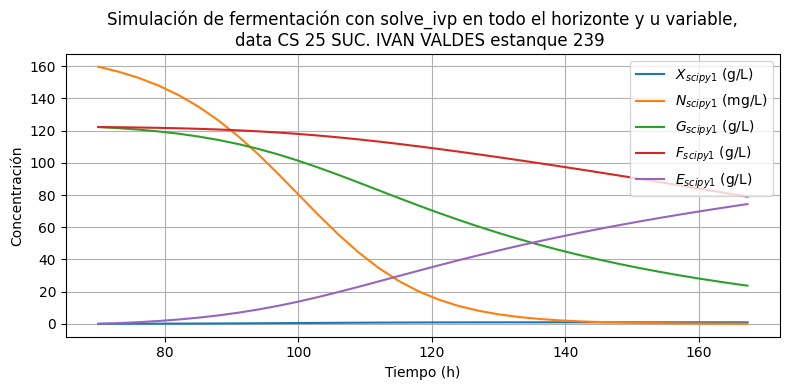

In [113]:
plt.figure(figsize=(8, 4))
plt.plot(res_datos1.t, res_datos1.y.T[:,0], '-', label='$X_{scipy1}$ (g/L)')
plt.plot(res_datos1.t, res_datos1.y.T[:,1]*1000, '-', label='$N_{scipy1}$ (mg/L)')
plt.plot(res_datos1.t, res_datos1.y.T[:,2], '-', label='$G_{scipy1}$ (g/L)')
plt.plot(res_datos1.t, res_datos1.y.T[:,3], '-', label='$F_{scipy1}$ (g/L)')
plt.plot(res_datos1.t, res_datos1.y.T[:,4], '-', label='$E_{scipy1}$ (g/L)')
plt.title('Simulación de fermentación con solve_ivp en todo el horizonte y u variable,\ndata CS 25 SUC. IVAN VALDES estanque 239 ')
plt.ylabel('Concentración')
plt.xlabel('Tiempo (h)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### Prueba 2

Data CS 24 AGROCAUQ estanque 68

In [114]:
path_excel_2 = r"C:\Users\MARIA\OneDrive - Universidad Católica de Chile\Escritorio\Concha y Toro\Datos históricos\CS\100.000 L\Data CS 24 AGROCAUQ estanque 68.xlsx"

In [116]:
out2 = process_excel(path_excel=path_excel_2,
        t_muestreo_h=3.0) # cada cuántas horas muestrear

In [160]:
x02 = np.array([out2.init.X0_gL, out2.init.N0_gL, 
             out2.init.G0_gL, out2.init.F0_gL, out2.init.E0_gL])
print(x02)


# x02 = np.array([0.15889697, 0.125, 121, 121, 0.0])

[  0.15889697   0.12546587 121.         121.           0.        ]


In [161]:
t_abs2 = out2.profiles.t_abs_h
temp_prom2 = out2.profiles.temp_promedio
Nadd2 = out2.profiles.Nadd_gL
tspan2 = (t_abs2[0], t_abs2[-1])

print(len(t_abs2), len(temp_prom2), len(Nadd2))

48 48 48


In [162]:
for i in range(len(Nadd2)): 
    if Nadd2[i] > 0.0:
        print(f"Adición de nitrógeno en t = {t_abs2[i]:.2f} h: Nadd = {Nadd2[i]:.3f} g/L/h")

Adición de nitrógeno en t = 84.14 h: Nadd = 0.048 g/L/h


In [163]:
res_datos2= solve_ivp(fun = zenteno_ode_u_variable, t_span = tspan2,  y0 = x02,  
                   method = 'LSODA', t_eval = t_abs2, 
                   args = (params, t_abs2, temp_prom2, Nadd2))

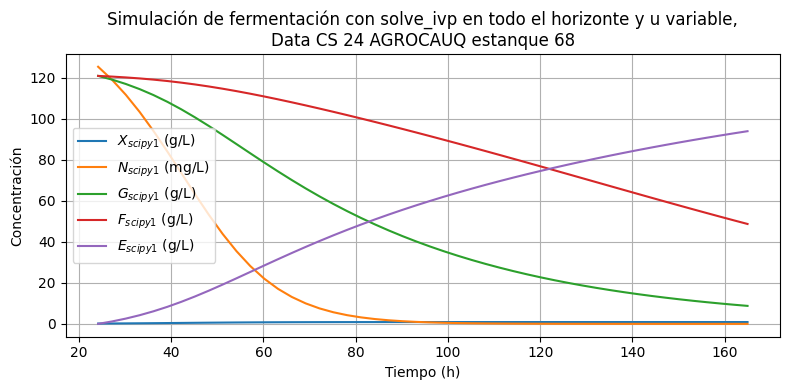

In [164]:
plt.figure(figsize=(8, 4))
plt.plot(res_datos2.t, res_datos2.y.T[:,0], '-', label='$X_{scipy1}$ (g/L)')
plt.plot(res_datos2.t, res_datos2.y.T[:,1]*1000, '-', label='$N_{scipy1}$ (mg/L)')
plt.plot(res_datos2.t, res_datos2.y.T[:,2], '-', label='$G_{scipy1}$ (g/L)')
plt.plot(res_datos2.t, res_datos2.y.T[:,3], '-', label='$F_{scipy1}$ (g/L)')
plt.plot(res_datos2.t, res_datos2.y.T[:,4], '-', label='$E_{scipy1}$ (g/L)')
plt.title('Simulación de fermentación con solve_ivp en todo el horizonte y u variable,\nData CS 24 AGROCAUQ estanque 68')
plt.ylabel('Concentración')
plt.xlabel('Tiempo (h)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

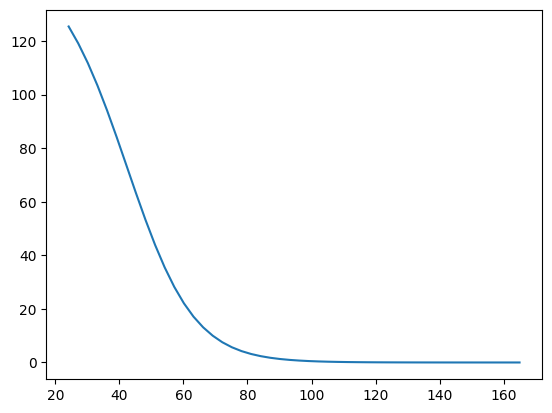

In [165]:
plt.Figure(figsize=(13, 8))
plt.plot(res_datos2.t, res_datos2.y.T[:,1]*1000, '-', label='$N_{scipy1}$ (mg/L)')
plt.show()

#### Prueba 3

Data CS 24 LOU estanque 54

In [166]:
path_excel_3 = r"C:\Users\MARIA\OneDrive - Universidad Católica de Chile\Escritorio\Concha y Toro\Datos históricos\CS\100.000 L\Data CS 24 LOU estanque 54.xlsx"

In [167]:
out3 = process_excel(path_excel=path_excel_3,
        t_muestreo_h=3.0) # cada cuántas horas muestrear

In [169]:
x03 = np.array([out3.init.X0_gL, out3.init.N0_gL, 
             out3.init.G0_gL, out3.init.F0_gL, out3.init.E0_gL])


print(f"x03 = {x03[0]:.3f}, {x03[1]:.3f}, {x03[2]:.3f}, {x03[3]:.3f}, {x03[4]:.3f}")


x03 = 0.033, 0.141, 122.216, 122.216, 0.000


In [170]:
t_abs3 = out3.profiles.t_abs_h
temp_prom3 = out3.profiles.temp_promedio
Nadd3 = out3.profiles.Nadd_gL
tspan3 = (t_abs3[0], t_abs3[-1])

print(len(t_abs3), len(temp_prom3), len(Nadd3))

48 48 48


In [171]:
for i in range(len(Nadd3)): 
    if Nadd3[i] > 0.0:
        print(f"Adición de nitrógeno en t = {t_abs3[i]:.2f} h: Nadd = {Nadd3[i]:.3f} g/L/h")

Adición de nitrógeno en t = 131.59 h: Nadd = 0.048 g/L/h


In [173]:
res_datos3= solve_ivp(fun = zenteno_ode_u_variable, t_span = tspan3,  y0 = x03,  
                   method = 'LSODA', t_eval = t_abs3, 
                   args = (params, t_abs3, temp_prom3, Nadd3))

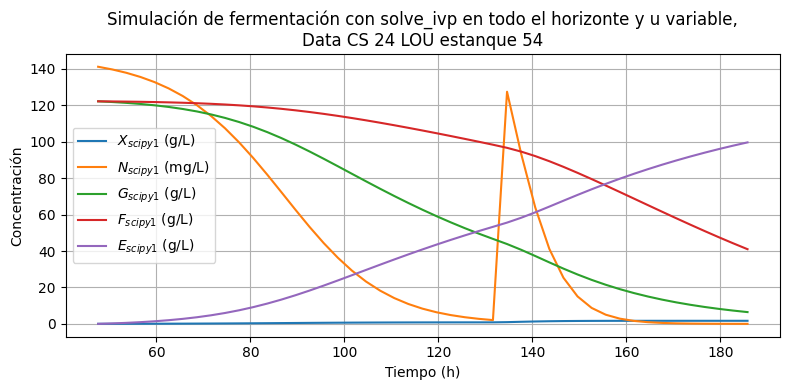

In [175]:
plt.figure(figsize=(8, 4))
plt.plot(res_datos3.t, res_datos3.y.T[:,0], '-', label='$X_{scipy1}$ (g/L)')
plt.plot(res_datos3.t, res_datos3.y.T[:,1]*1000, '-', label='$N_{scipy1}$ (mg/L)')
plt.plot(res_datos3.t, res_datos3.y.T[:,2], '-', label='$G_{scipy1}$ (g/L)')
plt.plot(res_datos3.t, res_datos3.y.T[:,3], '-', label='$F_{scipy1}$ (g/L)')
plt.plot(res_datos3.t, res_datos3.y.T[:,4], '-', label='$E_{scipy1}$ (g/L)')
plt.title('Simulación de fermentación con solve_ivp en todo el horizonte y u variable,\nData CS 24 LOU estanque 54')
plt.ylabel('Concentración')
plt.xlabel('Tiempo (h)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

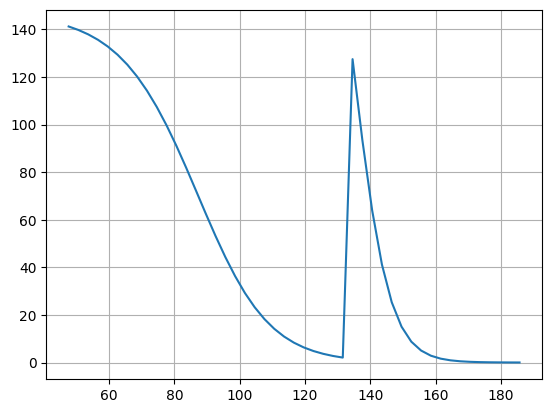

In [179]:
plt.Figure(figsize=(13, 8))
plt.plot(res_datos3.t, res_datos3.y.T[:,1]*1000, '-', label='$N_{scipy1}$ (mg/L)')
plt.grid(True)
plt.show()

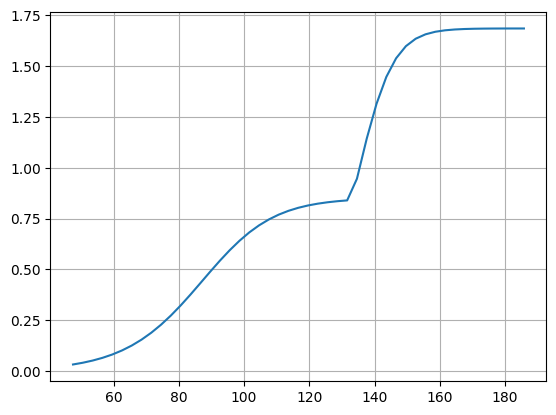

In [180]:
plt.Figure(figsize=(13, 8))
plt.plot(res_datos3.t, res_datos3.y.T[:,0], '-', label='$X_{scipy1}$ (g/L)')
plt.grid(True)
plt.show()